In [21]:
import re

import matplotlib.pyplot as plt
import pandas as pd

In [22]:
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["text.color"] = "black"
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.edgecolor"] = "black"
plt.rcParams["font.size"] = 11

In [23]:
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

pattern = re.compile(
    r"^\s*(\d+)\s+(\d+)\s+(\d+)\s+"
    r"(CPU|GPU naive|GPU row cache|GPU col cache|GPU tiled)\s+"
    r"([0-9.]+)\s+([0-9.]+)\s+(\- |\-|YES|NO)\s+([0-9.]+)\s*$",
    re.MULTILINE
)

rows = []
for m in pattern.finditer(text):
    N = int(m.group(1))
    S = int(m.group(2))
    UNROLL = int(m.group(3))
    algorithm = m.group(4).strip()
    time_ms = float(m.group(5))
    gflops = float(m.group(6))
    correct = m.group(7).strip()
    speedup = float(m.group(8))

    rows.append({
        "N": N,
        "S": S,
        "UNROLL": UNROLL,
        "Algorithm": algorithm,
        "Time_ms": time_ms,
        "GFLOPS": gflops,
        "Correct": correct,
        "Speedup": speedup
    })

df = pd.DataFrame(rows)
df

,N,S,UNROLL,Algorithm,Time_ms,GFLOPS,Correct,Speedup
0,256,8,1,CPU,8.4412,3.975080,-,1.000000
1,256,8,1,GPU naive,88.8588,0.377615,YES,0.094996
2,256,8,1,GPU row cache,2.1242,15.796300,YES,3.973830
3,256,8,1,GPU col cache,1.9608,17.112600,YES,4.304980
4,256,8,1,GPU tiled,1.5769,21.278700,YES,5.353030
...,...,...,...,...,...,...,...,...
175,1024,32,8,CPU,2356.1000,0.911456,-,1.000000
176,1024,32,8,GPU naive,65.1253,32.974600,YES,36.178000
177,1024,32,8,GPU row cache,53.9503,39.804900,YES,43.671700
178,1024,32,8,GPU col cache,175.0660,12.266700,YES,13.458300


In [24]:
print("Rows parsed:", len(df))
print("N values:", sorted(df["N"].unique()))
print("S values:", sorted(df["S"].unique()))
print("UNROLL values:", sorted(df["UNROLL"].unique()))
print("Algorithms:", list(df["Algorithm"].unique()))

Rows parsed: 180
N values: [np.int64(256), np.int64(512), np.int64(1024)]
S values: [np.int64(8), np.int64(16), np.int64(32)]
UNROLL values: [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]
Algorithms: ['CPU', 'GPU naive', 'GPU row cache', 'GPU col cache', 'GPU tiled']


In [25]:
styles = {
    "CPU": {"marker": "o", "linestyle": "-", "linewidth": 2.5},
    "GPU naive": {"marker": "s", "linestyle": "--", "linewidth": 2.5},
    "GPU row cache": {"marker": "^", "linestyle": "-.", "linewidth": 2.5},
    "GPU col cache": {"marker": "D", "linestyle": ":", "linewidth": 2.5},
    "GPU tiled": {"marker": "x", "linestyle": "-", "linewidth": 3.0},
}

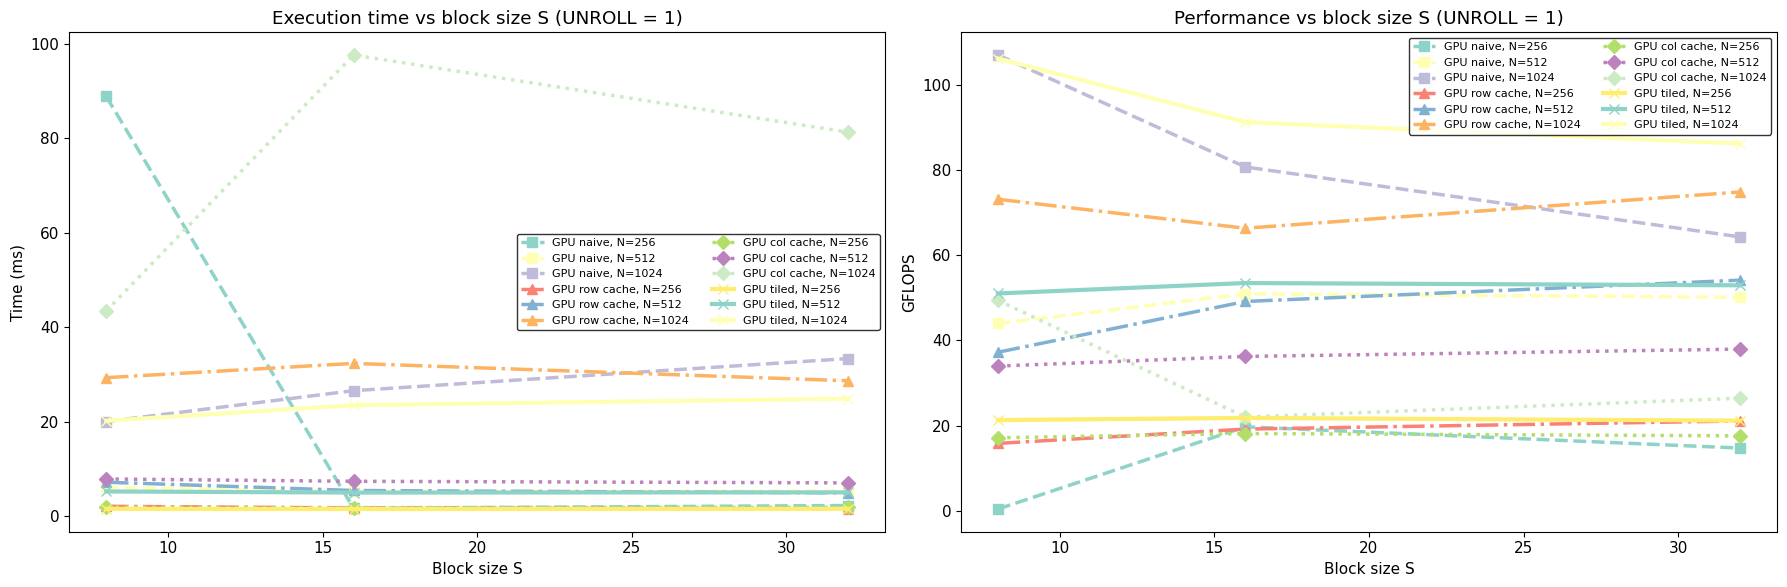

In [26]:
unroll_for_S = 1

df_s = df[(df["UNROLL"] == unroll_for_S) & (df["Algorithm"] != "CPU")].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("white")

for algo in ["GPU naive", "GPU row cache", "GPU col cache", "GPU tiled"]:
    for N in sorted(df_s["N"].unique()):
        part = df_s[(df_s["Algorithm"] == algo) & (df_s["N"] == N)].sort_values("S")
        if len(part) == 0:
            continue

        label = f"{algo}, N={N}"
        style = styles[algo]

        axes[0].plot(
            part["S"], part["Time_ms"],
            label=label,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7
        )

        axes[1].plot(
            part["S"], part["GFLOPS"],
            label=label,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7
        )

axes[0].set_title(f"Execution time vs block size S (UNROLL = {unroll_for_S})")
axes[0].set_xlabel("Block size S")
axes[0].set_ylabel("Time (ms)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f"Performance vs block size S (UNROLL = {unroll_for_S})")
axes[1].set_xlabel("Block size S")
axes[1].set_ylabel("GFLOPS")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend(fontsize=8, ncol=2)
    ax.set_facecolor("white")

plt.tight_layout()
plt.show()

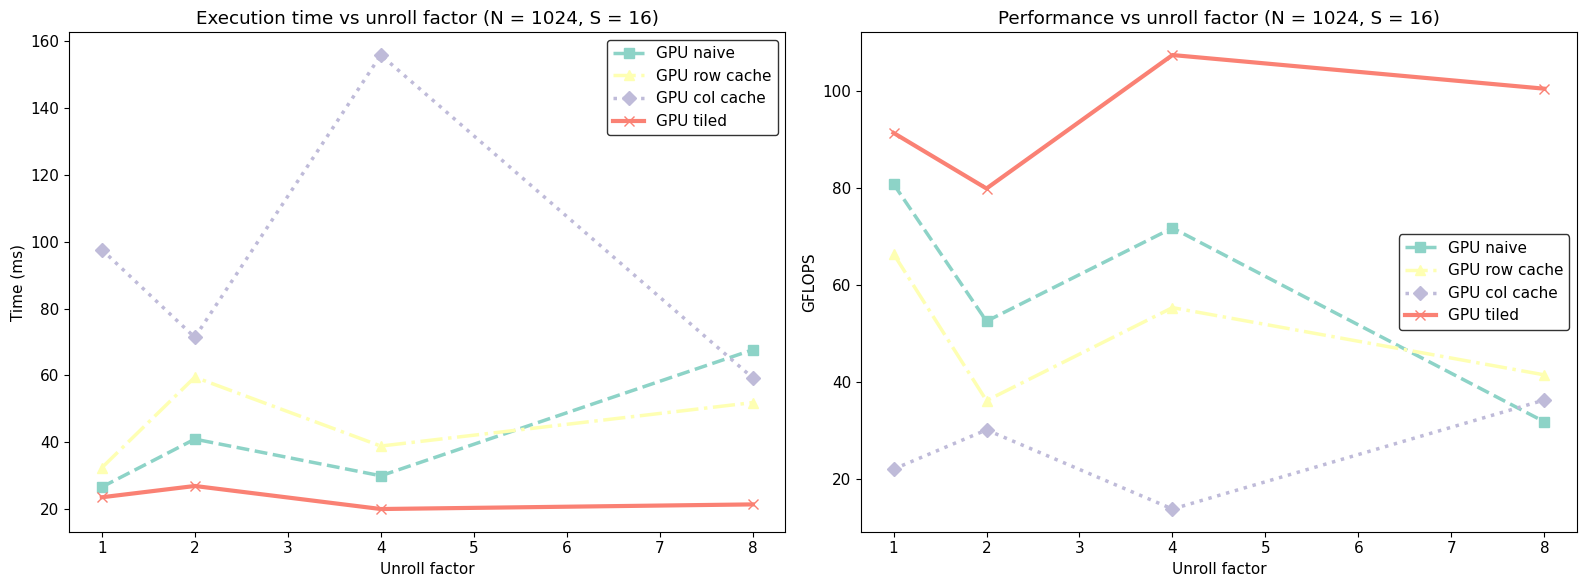

In [27]:
N_unroll = 1024
S_unroll = 16

df_unroll = df[
    (df["N"] == N_unroll) &
    (df["S"] == S_unroll) &
    (df["Algorithm"] != "CPU")
    ].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("white")

for algo in ["GPU naive", "GPU row cache", "GPU col cache", "GPU tiled"]:
    part = df_unroll[df_unroll["Algorithm"] == algo].sort_values("UNROLL")
    if len(part) == 0:
        continue

    style = styles[algo]

    axes[0].plot(
        part["UNROLL"], part["Time_ms"],
        label=algo,
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        markersize=7
    )

    axes[1].plot(
        part["UNROLL"], part["GFLOPS"],
        label=algo,
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        markersize=7
    )

axes[0].set_title(f"Execution time vs unroll factor (N = {N_unroll}, S = {S_unroll})")
axes[0].set_xlabel("Unroll factor")
axes[0].set_ylabel("Time (ms)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f"Performance vs unroll factor (N = {N_unroll}, S = {S_unroll})")
axes[1].set_xlabel("Unroll factor")
axes[1].set_ylabel("GFLOPS")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()
    ax.set_facecolor("white")

plt.tight_layout()
plt.show()

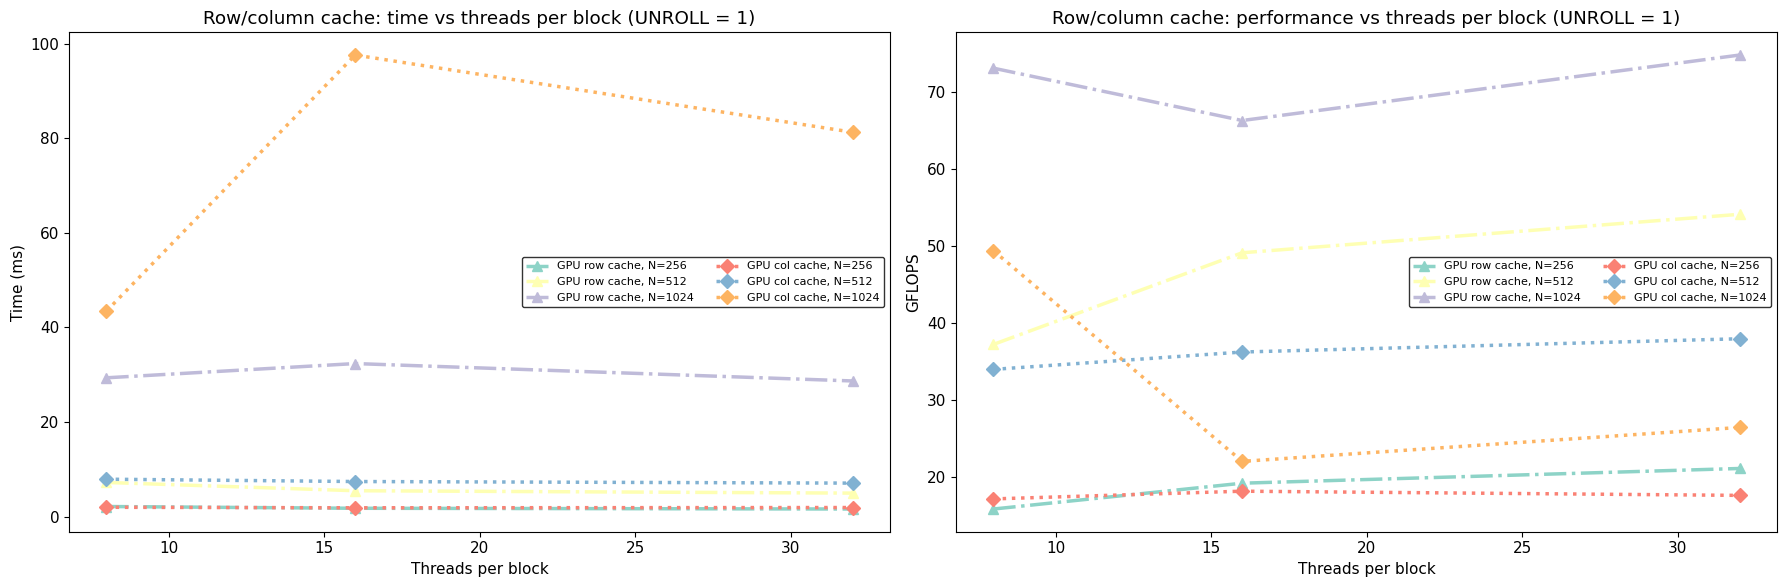

In [28]:
unroll_for_cache = 1

df_cache = df[
    (df["UNROLL"] == unroll_for_cache) &
    (df["Algorithm"].isin(["GPU row cache", "GPU col cache"]))
    ].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("white")

for algo in ["GPU row cache", "GPU col cache"]:
    for N in sorted(df_cache["N"].unique()):
        part = df_cache[(df_cache["Algorithm"] == algo) & (df_cache["N"] == N)].sort_values("S")
        if len(part) == 0:
            continue

        label = f"{algo}, N={N}"
        style = styles[algo]

        axes[0].plot(
            part["S"], part["Time_ms"],
            label=label,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7
        )

        axes[1].plot(
            part["S"], part["GFLOPS"],
            label=label,
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=7
        )

axes[0].set_title(f"Row/column cache: time vs threads per block (UNROLL = {unroll_for_cache})")
axes[0].set_xlabel("Threads per block")
axes[0].set_ylabel("Time (ms)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f"Row/column cache: performance vs threads per block (UNROLL = {unroll_for_cache})")
axes[1].set_xlabel("Threads per block")
axes[1].set_ylabel("GFLOPS")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend(fontsize=8, ncol=2)
    ax.set_facecolor("white")

plt.tight_layout()
plt.show()